# Предсказание исхода шахматной партии

## Задача

*Требуется предсказать win / not win для новых партий, которые я играю*

#### Признаки до начала игры:

- Разница рейтингов
- Цвет фигур

#### Признаки в некоторый момент игры:

- Номер хода
- Мои фигуры на доске
- Преимущество по фигурам
- Оставшееся у меня время
- Преимущество по времени

#### Выбор модели

| Модель                | Роль       | Преимущества                           |
|-----------------------|------------|----------------------------------------|
| Logistic Regression   | Baseline   | Простая, легко интерпретировать        |
| Gradient Boosting     | Prediction | Нелинейности, взаимодействия признаков |

## Подготовка окружения

Перед запуском `lichess.ipynb` необходимо выполнить следующие команды

```bash
./tools/install.sh
source .venv/bin/activate
python tools/get_data.py
```

## Импорты

In [258]:
import pandas as pd

import chess
import chess.pgn

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import curve_fit

import re
from   datetime import datetime

from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import roc_auc_score

import lightgbm as lgb

import optuna

## Исходные данные

#### Пример записи одной игры

In [259]:
with open("data.pgn") as f:
    print(chess.pgn.read_game(f))

[Event "rated blitz game"]
[Site "https://lichess.org/Lnhx4IvX"]
[Date "2026.04.29"]
[Round "-"]
[White "qorovin"]
[Black "crazyhandrick"]
[Result "0-1"]
[GameId "Lnhx4IvX"]
[UTCDate "2026.04.29"]
[UTCTime "12:58:46"]
[WhiteElo "1309"]
[BlackElo "1297"]
[WhiteRatingDiff "-6"]
[BlackRatingDiff "+6"]
[Variant "Standard"]
[TimeControl "300+3"]
[ECO "C44"]
[Opening "Ponziani Opening"]
[Termination "Time forfeit"]

1. e4 { [%clk 0:05:00] } 1... e5 { [%clk 0:05:00] } 2. Nf3 { [%clk 0:05:02] } 2... Nc6 { [%clk 0:05:00] } 3. c3 { [%clk 0:05:05] } 3... d6 { [%clk 0:05:01] } 4. d4 { [%clk 0:05:00] } 4... Bg4 { [%clk 0:05:02] } 5. d5 { [%clk 0:04:59] } 5... Bxf3 { [%clk 0:05:04] } 6. Qxf3 { [%clk 0:04:57] } 6... Nce7 { [%clk 0:05:00] } 7. Bb5+ { [%clk 0:04:54] } 7... c6 { [%clk 0:05:01] } 8. dxc6 { [%clk 0:04:50] } 8... bxc6 { [%clk 0:05:02] } 9. Bc4 { [%clk 0:04:46] } 9... Nf6 { [%clk 0:05:00] } 10. Bg5 { [%clk 0:04:36] } 10... Ng6 { [%clk 0:04:58] } 11. Bxf6 { [%clk 0:04:30] } 11... gxf6 { [%cl

#### Как формировать признаки

| Признаки                | Изменения                                                |
|-------------------------|----------------------------------------------------------|
| `Variant`               |    Оставить только `"Variant = Standard"`                |
| `WhiteElo` + `BlackElo` | -> Мой рейтинг минус рейтинг соперника `rate_d`          |
| `White` + `Black`       | -> Цвет моих фигур `color`                               |
| `Запись ходов`          | -> `moves [ (sec=300, sec_d=0, mat=39, mat_d=0) , ... ]`<br>Список записей после каждого хода:<br>`sec` = сколько осталось секунд у меня<br>`sec_d` = сколько осталось секунд у меня минус у соперника<br>`mat` = суммарный вес фигур у меня<br>`mat_d` = суммарный вес фигур у меня минус у соперника                                                                            |
| `Result`                | -> Исход партии (one-hot) `win` `draw` `loss`            |

## Создание `df`

Константы

In [260]:
NICK     = "qorovin"
SEC_INIT = 300

PIECE_VALUES = {
    chess.PAWN:   1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK:   5,
    chess.QUEEN:  9,
}

`date`

In [261]:
def get_date(headers):
    return datetime.strptime(headers["UTCDate"], "%Y.%m.%d").toordinal()

`rate` `rate_d`

In [262]:
def get_rate(headers, is_white):
    return int(headers["WhiteElo"]) if is_white else int(headers["BlackElo"])

def get_rate_d(headers, is_white):
    return (int(headers["WhiteElo"]) - int(headers["BlackElo"])) * (1 if is_white else -1)

`win` `draw` `loss`

In [263]:
def get_result(headers, is_white):
    if headers["Result"] == "1/2-1/2":
        win, draw, loss = 0, 1, 0
    elif (headers["Result"] == "1-0") == is_white:
        win, draw, loss = 1, 0, 0
    else:
        win, draw, loss = 0, 0, 1
    return win, draw, loss

`moves`

In [264]:
def parse_clock(comment):
    m = re.search(r'\[%clk 0:(\d+):(\d+)\]', comment)
    return int(m.group(1)) * 60 + int(m.group(2)) if m else None

def count_material(board, color):
    return sum(len(board.pieces(pt, color)) * val for pt, val in PIECE_VALUES.items())

def material_advantage(board, my_color):
    return count_material(board, my_color) - count_material(board, not my_color)

def parse_moves(game, my_color):
    opp_color = not my_color
    moves  = []
    clocks = {chess.WHITE: SEC_INIT, chess.BLACK: SEC_INIT}
    node = game
    while node.variations:
        node = node.variations[0]
        mover = node.parent.board().turn
        clk   = parse_clock(node.comment)
        if clk is not None:
            if mover == my_color:
                board = node.board()
                mat   = count_material(board, my_color)
                mat_d = material_advantage(board, my_color)
                moves.append((clk, clk - clocks[opp_color], mat, mat_d))
            clocks[mover] = clk
    return moves

#### Парсинг

In [265]:
with open("data.pgn") as f:
    rows = []
    while True:
        game = chess.pgn.read_game(f)
        if game is None:
            break
        headers = game.headers
        if headers.get("Variant", "Standard") != "Standard":
            continue
        is_white = (headers["White"] == NICK)
        win, draw, loss = get_result(headers, is_white)
        rows.append({
            "date":      get_date(headers),
            "color":     int(is_white),
            "rate":      get_rate(headers, is_white),
            "rate_d":    get_rate_d(headers, is_white),
            "win":       win,
            "draw":      draw,
            "loss":      loss,
            "moves":     parse_moves(game, chess.WHITE if is_white else chess.BLACK)
        })

df = pd.DataFrame(rows[::-1])

date = df["date"]
df["date"] = (date - date.min()) / (date.max() - date.min())

df.shape

(2052, 8)

In [266]:
pd.concat([df.head(3), df.tail(3)])

,date,color,rate,rate_d,win,draw,loss,moves
0,0.000000,0,920,-21,0,0,1,"[(300, 0, 39, 0), (301, 1, 39, 0), (301, 0, 39..."
1,0.030508,1,719,-16,0,0,1,"[(300, 0, 39, 0), (296, -4, 39, 0), (288, -8, ..."
2,0.030508,0,713,-32,1,0,0,"[(300, 0, 39, 0), (291, 11, 39, 0), (291, 15, ..."
2049,0.997740,1,1315,23,0,0,1,"[(300, 0, 39, 0), (302, 2, 39, 1), (293, -8, 3..."
2050,0.998870,0,1309,-13,0,1,0,"[(300, 0, 39, 0), (301, 0, 39, 0), (301, 2, 39..."
2051,1.000000,1,1309,12,0,0,1,"[(300, 0, 39, 0), (302, 2, 39, 0), (305, 5, 39..."


## EDA

#### Мой рейтинг `rate` в зависимости от даты игры `date`<br>*-> Веса для обучения `w_train`*

Как менялся рейтинг со временем

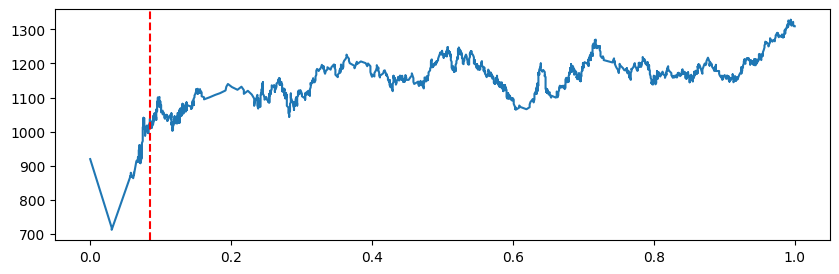

In [267]:
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(df["date"], df["rate"])
_ = ax.axvline(x=0.085, color="red", linestyle="--")

Уберем самые настабильные партии

In [268]:
df = df[df["date"] > 0.085]

Аппрокимируем рейтинг логарифмом

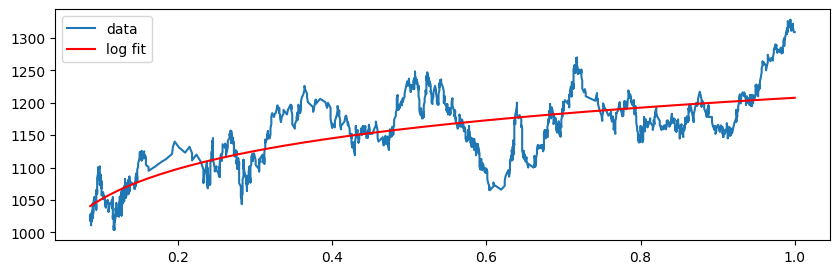

In [269]:
def log_func(x, a, b):
    return a * np.log(x) + b

x = df["date"].values
y = df["rate"].values

popt, _ = curve_fit(log_func, x, y)
y_log   = log_func(x, *popt)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x, y, label="data")
ax.plot(x, y_log, color="red", label="log fit")
_ = ax.legend()

Получим веса для обучения `w_train`  
Получается, вес учитывает давность игры и колебания рейтинга. Прекрасно

In [270]:
df["w_train"] = (y_log - y_log.min()) / (y_log.max() - y_log.min()) + 1e-6

Изменение весов для выборки изменило AUC только для линейной модели:  
`0.697 -> 0.707`

#### Матрица корреляций для признаков перед началом игры

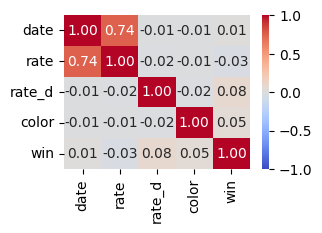

In [271]:
features = ["date", "rate", "rate_d", "color", "win"]

plt.figure(figsize=(3,2))
_ = sns.heatmap(df[features].corr(), vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f")

#### Соотношение `win` `draw` `loss` в зависимости от цвета

Победы и поражения сбалансированны

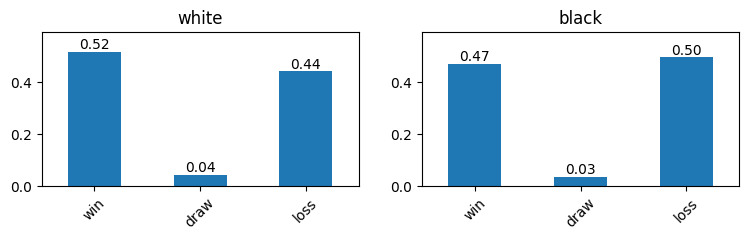

In [272]:
rates_w = df[df["color"] == 1][["win", "draw", "loss"]].mean()
rates_b = df[df["color"] == 0][["win", "draw", "loss"]].mean()

fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(9,2))

ax_w = rates_w.plot.bar(ax=ax_w, title="white")
ax_b = rates_b.plot.bar(ax=ax_b, title="black")

for ax, rates in [(ax_w, rates_w), (ax_b, rates_b)]:
    ax.tick_params(axis="x", rotation=45)
    for p in ax.patches:
        text  = f"{p.get_height():.2f}"
        xy    = (p.get_x() + p.get_width() / 2, p.get_height())
        ax.annotate(text, xy, ha="center", va="bottom", )
    ax.set_ylim(0, rates_w.max() * 1.15)

#### Сколько партий по разнице в рейтинге соперников `rate_d` <br>*-> Feature engineering*

**Наблюдение**  

Партии `rate_d < -130` встречаются редко и непредсказуемы  

Интерпретация:  
Почти всегда такая разника в рейтинге означает игру с новым пользователем, которому система присваивает `rate = 1500` до калибровки. В этом случае признак `rate_d` неинформативен: неизвестно, насколько хорошо играет соперник.

**Решение**  

~~Добавил признак `is_newbie = (rate_d < -130).astype(int)`  ~~

**Результат**  

Метрики не изменились, удалил признак.

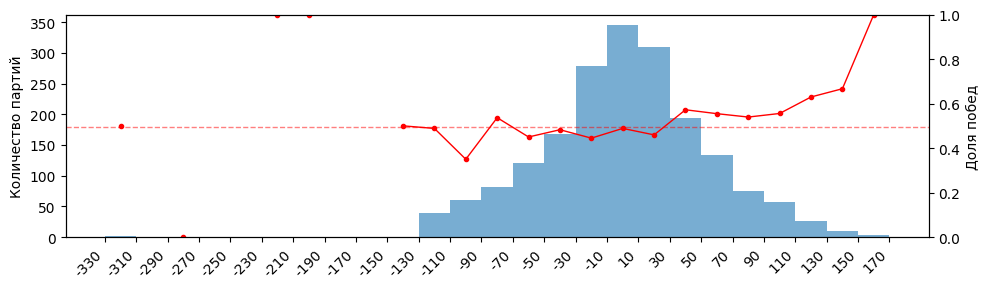

In [273]:
fig, ax1 = plt.subplots(figsize=(10, 3))

# Количество партий (столбцы)

counts, bin_edges, _ = ax1.hist(df["rate_d"], bins=25, alpha=0.6)
ax1.set_xticks(bin_edges)
ax1.set_xticklabels([f"{e:.0f}" for e in bin_edges], rotation=45, ha="right")
ax1.set_ylabel("Количество партий")

# Доля побед (линия)

ax2 = ax1.twinx()

bins_cut = pd.cut(df["rate_d"], bins=bin_edges, include_lowest=True)
winrate  = df.groupby(bins_cut, observed=False)["win"].mean()
centers  = (bin_edges[:-1] + bin_edges[1:]) / 2

ax2.plot(centers, winrate.values, color="red", linewidth=1, marker="o", markersize=3)
ax2.axhline(y=df["win"].mean(), color="red", linewidth=1, linestyle="--", alpha=0.5)
ax2.set_ylabel("Доля побед")
ax2.set_ylim(0, 1)

plt.tight_layout()

#### Сколько партий по количеству ходов в игре

Партии c числом ходов больше 70 встречаются редко.  
Мало материвала для обучения предсказания на ходе `move_n > 70`.

Такие ходы редки, поэтому на общую метрику это почти не влияет.

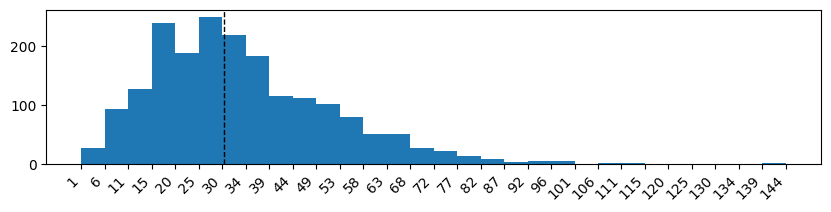

In [274]:
fig, ax = plt.subplots(figsize=(10, 2))

move_counts = df["moves"].apply(len)
counts, bin_edges, patches = ax.hist(move_counts, bins=30)

ax.set_xticks(bin_edges)
ax.set_xticklabels([f"{e:.0f}" for e in bin_edges], rotation=45, ha="right")

# медиана
_ = ax.axvline(x=move_counts.median(), color="black", linewidth=1, linestyle="--")

#### Медианы признаков по номеру хода `move_n` <br>(графики для победных и проигранных партий) <br>*-> Feature engineering*

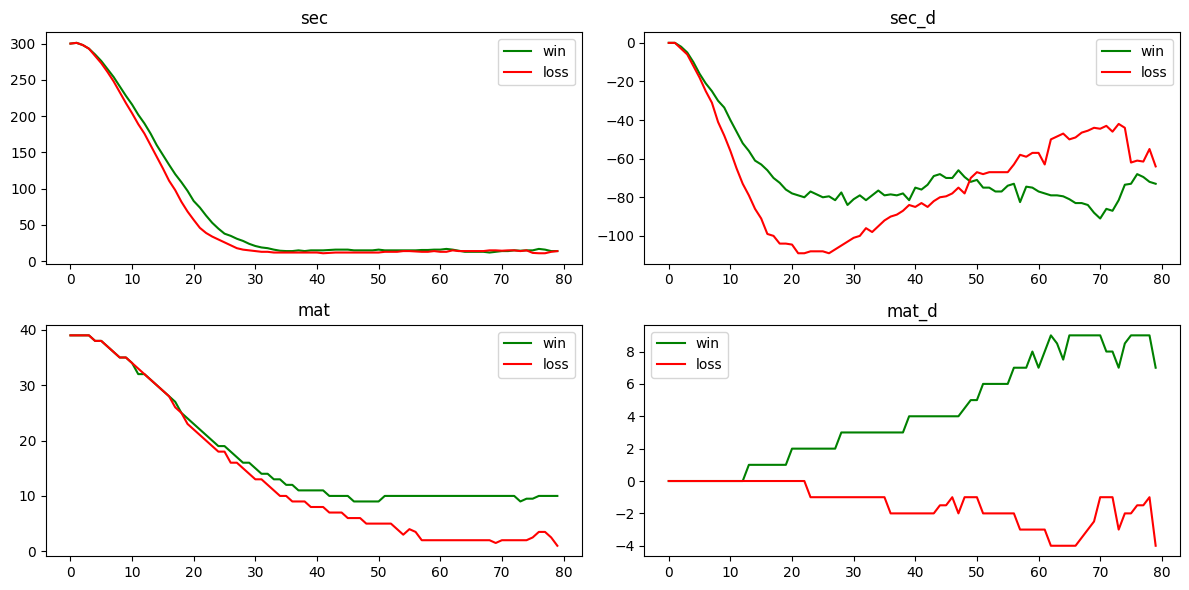

In [275]:
MOVE_N   = 80
FEATURES = [(0, "sec"), (1, "sec_d"), (2, "mat"), (3, "mat_d")]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for ax, (idx, name) in zip(axes.flat, FEATURES):
    for outcome, label, color in [(1, "win", "green"), (0, "loss", "red")]:
        subset = df[df["win"] == outcome]["moves"]
        medians = [
            subset.apply(lambda m, n=n: m[n][idx] if len(m) > n else None).median()
            for n in range(MOVE_N)
        ]
        ax.plot(medians, label=label, color=color)
    ax.set_title(name)
    ax.legend()

plt.tight_layout()

##### `sec`

**Наблюдение**  

Признак `sec` информативен только в связке `sec_d`  

**Решение**  

В `df_moves` заменить `"sec": sec` на относительную величину  
`"sec_ratio":  sec / (sec + max(sec - sec_d, 0) + 1)`  

Это число в диапазоне `[0, 1]` – доля моего оставшегося времени  

**Результат**  

```
LR val AUC  0.690 -> 0.697
GB val AUC  0.706 -> 0.707
```

##### `sec_d`

**Наблюдение**  

Признак `sec_d` меняет тенденцию, начиная с `move_n > 50`:  
отставание по времени в случае `win` становится больше, чем в случае `loss`  

Это нелинейность по `move_n`:  
один и тот же `sec_d` означает разное в дебюте и в эндшпиле

**Решение**  

~~Добавил признаки фазы партии и взаимодействия `sec_d` с фазой партии:~~  

~~`"is_endgame":    int(move_n > 40)`~~  
~~`"sec_d_endgame": sec_d * int(move_n > 40)`~~


**Результат**

Метрики в среднем немного упали – убрал эти признаки

```
LR val AUC  0.707 -> 0.704
GB val AUC  0.707 -> 0.708
```

##### `mat`

**Наблюдение**

Признак `mat` информативен только в связке `mat_d`

**Решение**  

В `df_moves` заменить `"mat": mat` на относительную величину  
`"mat_ratio":  mat / (mat + max(mat - mat_d, 0) + 1)`  

Это число в диапазоне `[0, 1]` – доля моего материального преимущества  

**Результат**  

```
LR val AUC  0.705 -> 0.710
GB val AUC  0.706 -> 0.711
```

## Создание `df_moves`

In [276]:
rows_ml = []

for game_id, row in df.iterrows():
    for move_n, (sec, sec_d, mat, mat_d) in enumerate(row["moves"]):
        rows_ml.append({
            "game_id":       game_id,
            "w_train":       row["w_train"],
            "color":         row["color"],
            "rate_d":        row["rate_d"],
            "move_n":        move_n,
            "sec_d":         sec_d,
            "sec_ratio":     sec / (sec + max(sec - sec_d, 0) + 1),
            "mat_d":         mat_d,
            "mat_ratio":     mat / (mat + max(mat - mat_d, 0) + 1),
            "win":           row["win"],
        })

df_moves = pd.DataFrame(rows_ml)

df_moves.shape

(63864, 10)

In [277]:
pd.concat([df_moves.head(3), df_moves.tail(3)])

,game_id,w_train,color,rate_d,move_n,sec_d,sec_ratio,mat_d,mat_ratio,win
0,142,0.000001,1,-38,0,0,0.499168,0,0.493671,0
1,142,0.000001,1,-38,1,2,0.500829,0,0.493671,0
2,142,0.000001,1,-38,2,2,0.500824,1,0.500000,0
63861,2051,1.000001,1,12,25,-260,0.032258,1,0.500000,0
63862,2051,1.000001,1,12,26,-252,0.026217,1,0.500000,0
63863,2051,1.000001,1,12,27,-254,0.018868,1,0.500000,0


## Разделение `train` + `val` + `test`

```
[========== train ==========][== val ==][== test ==]
             70%                 15%         15%    
```

Так как требуется качественное предсказание исхода **новой** партии,  
`df` уже отсортирован по возрастанию даты игры `date`  

То есть в `train` живут самые давние партии, а в `test` – самые новые

In [278]:
FEATURES = [
    "color",
    "rate_d",
    "move_n",
    "sec_d",
    "sec_ratio",
    "mat_d",
    "mat_ratio"
]

n_train = int(len(df) * 0.70)
n_val   = int(len(df) * 0.85)

train_games = set(df.index[         : n_train ])
val_games   = set(df.index[ n_train : n_val   ])
test_games  = set(df.index[   n_val :         ])

df_train = df_moves[df_moves["game_id"].isin(train_games)]
df_val   = df_moves[df_moves["game_id"].isin(val_games)]
df_test  = df_moves[df_moves["game_id"].isin(test_games)]

w_train = df_train["w_train"]

X_train, y_train = df_train[FEATURES], df_train["win"].values
X_val,   y_val   = df_val[FEATURES],   df_val["win"].values
X_test,  y_test  = df_test[FEATURES],  df_test["win"].values

print(f"train: {len(train_games)} партий, {len(df_train)} строк")
print(f"val:   {len(val_games)}   партий, {len(df_val)}   строк")
print(f"test:  {len(test_games)}  партий, {len(df_test)}  строк")

train: 1337 партий, 44435 строк
val:   286   партий, 9460   строк
test:  287  партий, 9969  строк


In [279]:
assert set(df_train["game_id"]).isdisjoint(set(df_val["game_id"]))
assert set(df_val["game_id"]).isdisjoint(set(df_test["game_id"]))
assert set(df_train["game_id"]).isdisjoint(set(df_test["game_id"]))
print("Партии не пересекаются")

Партии не пересекаются


## ML

### LogReg

In [280]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # transform + get μ, σ
X_val_sc   = scaler.transform(X_val)        # transform + use μ, σ
X_test_sc  = scaler.transform(X_test)       # transform + use μ, σ

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_sc, y_train, sample_weight=w_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### LightGBM

##### Optuna

In [ ]:
def objective(trial):

    params = {
        # макс. кол-во деревьев
        #  реально: ealry stopping
        "n_estimators": 1000,
        # коэффициент вклада нового дерева
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),

        # макс. глубина дерева
        "max_depth": trial.suggest_int  ("max_depth", 2, 12),
        # макс. кол-во листьев
        "num_leaves": trial.suggest_int  ("num_leaves", 5, 200),
        # мин. кол-во примеров в листе
        "min_child_samples": trial.suggest_int  ("min_child_samples", 5, 3000),
        # мин. улучшение loss для разделения после узла
        "min_split_gain": 0.0,

        # L1-штраф на уверенность предсказания в листьях
        #  обнуляет некоторые предсказания
        "reg_alpha": trial.suggest_float("reg_alpha",  0.0, 10.0),
        # L2-штраф на уверенность предсказания в листьях
        #  сжимает предсказания к нулю
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),

        # доля (случайных) строк для дерева
        #  остальные оно не увидит
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        # как часто перевыбирать (случайные) строки для дерева
        "subsample_freq": 1,
        # доля (случайных) признаков для дерева
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.2, 1.0),

        # используется для инициализации и параметров сэплирования
        #  дает воспроизводимость
        "random_state": 42,
        # отключить логи
        "verbose": -1,
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight = w_train,
        eval_set      = [(X_val, y_val)], # check early_stopping
        callbacks     = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)],
    )

    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

In [ ]:
%%script true

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

Best trial: 41. Best value: 0.729749: 100%|██████████| 200/200 [01:59<00:00,  1.68it/s]

Best AUC: 0.7297486115072906
Best params: {'learning_rate': 0.10102500777837997, 'max_depth': 7, 'num_leaves': 186, 'min_child_samples': 2315, 'reg_alpha': 8.047068852560674, 'reg_lambda': 8.86519110073542, 'subsample': 0.5125927222229948, 'colsample_bytree': 0.9499446010612463}


Прирост AUC после регуляризации ≈ 0.012

##### LightGBM

In [309]:
model_lgb = lgb.LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.10102500777837997,
    max_depth         = 7,
    num_leaves        = 186,
    min_child_samples = 2315,
    reg_alpha         = 8.047068852560674,
    reg_lambda        = 8.86519110073542,
    subsample         = 0.5125927222229948,
    colsample_bytree  = 0.9499446010612463,
    random_state      = 42,
    verbose           = -1
)

model_lgb.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)],
)

,boosting_type,'gbdt'
,num_leaves,186
,max_depth,7
,learning_rate,0.10102500777837997
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,2315


## AUC on `val`

In [297]:
def fit_status(auc_train, auc_val):
    diff = auc_train - auc_val
    if   diff >  0.02: status = "overfit"
    elif diff < -0.02: status = "underfit"
    else:              status = "good fit"
    print(f"train {auc_train:.3f} | val {auc_val:.3f} | {status}")

#### LogReg' AUC

In [298]:
auc_lr_train = roc_auc_score(y_train, model_lr.predict_proba(X_train_sc)[:, 1])
auc_lr_val   = roc_auc_score(y_val,   model_lr.predict_proba(X_val_sc)[:, 1])

fit_status(auc_lr_train, auc_lr_val)

train 0.732 | val 0.711 | overfit


#### LightGBM' AUC

In [310]:
auc_lgb_train = roc_auc_score(y_train, model_lgb.predict_proba(X_train)[:, 1])
auc_lgb_val   = roc_auc_score(y_val,   model_lgb.predict_proba(X_val)[:, 1])

fit_status(auc_lgb_train, auc_lgb_val)

train 0.750 | val 0.723 | overfit


## Feature importance

#### LightGBM' feature importance

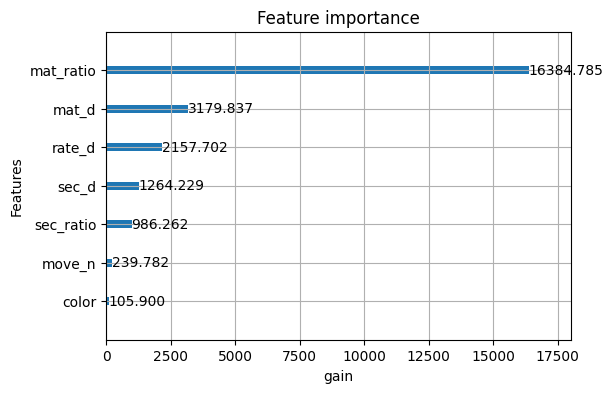

In [301]:
_ = lgb.plot_importance(model_lgb, importance_type="gain", figsize=(6, 4), xlabel="gain")

#### LogReg' feature importance

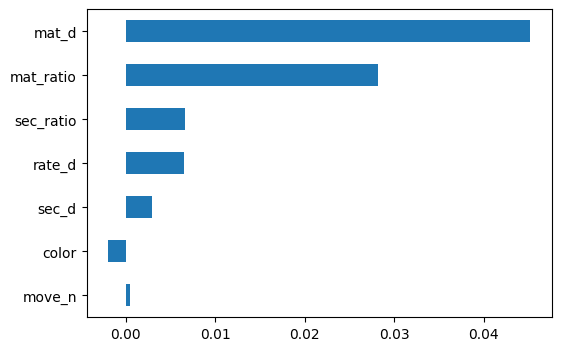

In [302]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model_lr, X_val_sc, y_val, n_repeats=10, random_state=42)

importance = pd.Series(result.importances_mean, index=X_train.columns)
importance = importance.reindex(importance.abs().sort_values(ascending=True).index)

_ = importance.plot(kind="barh", figsize=(6, 4))

## AUC on `test`

#### LogReg' AUC

In [304]:
# auc_lr_test = roc_auc_score(y_test, model_lr.predict_proba(X_test_sc)[:, 1])
# fit_status(auc_lr_train, auc_lr_test)

#### LightGBM' AUC

In [307]:
# auc_lgb_test = roc_auc_score(y_test, model_lgb.predict_proba(X_test)[:, 1])
# fit_status(auc_lgb_train, auc_lgb_test)

### Сравнение AUC по номеру хода

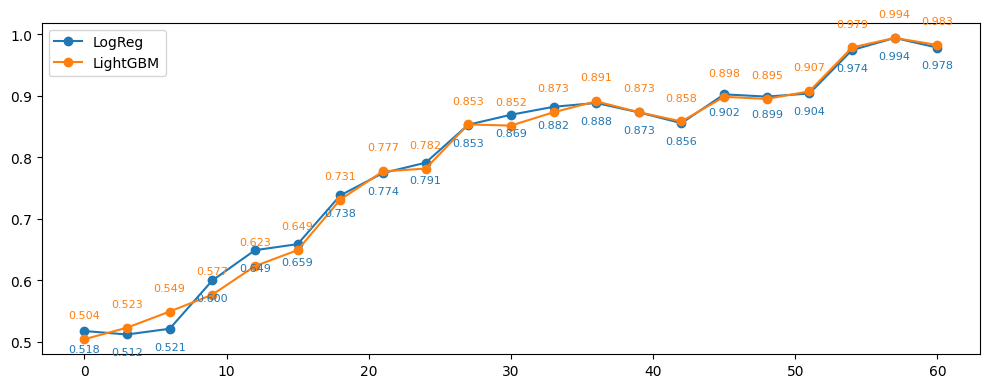

In [308]:
ns, aucs_lr, aucs_lgb = [], [], []

for n in range(0, 100, 3):
    
    mask = (df_test["move_n"] == n)
    # Если меньше 10 партий с таким количеством ходов
    if mask.sum() < 30:
        continue

    # .loc[строки, столбцы]
    X_n = df_test.loc[mask, FEATURES]
    y_n = df_test.loc[mask, "win"]

    ns.append(n)
    aucs_lr.append(roc_auc_score(y_n, model_lr.predict_proba(scaler.transform(X_n))[:, 1]))
    aucs_lgb.append(roc_auc_score(y_n, model_lgb.predict_proba(X_n)[:, 1]))

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ns, aucs_lr,  marker="o", label="LogReg")
ax.plot(ns, aucs_lgb, marker="o", label="LightGBM")

ax.legend()

for x, y_lr, y_lgb in zip(ns, aucs_lr, aucs_lgb):
    ax.annotate(f"{y_lr:.3f}",  (x, y_lr),  textcoords="offset points", xytext=(0, -15), ha="center", color="C0", fontsize=8)
    ax.annotate(f"{y_lgb:.3f}", (x, y_lgb), textcoords="offset points", xytext=(0, +15), ha="center", color="C1", fontsize=8)

plt.tight_layout()

## Вывод

**Природа задачи**  
- На ранней стадии игры, когда `mat_raio` мал, предсказать исход партии достаточно сложно. Это дает ограничение для качества предсказания и тянет AUC вниз.  

**Малый объем данных и разнообразие признаков**  
- AUC линейной и бустинг моделей почти одинаковый
- Optuna предлагает маленькие деревья (`max_depth=7`, но `min_child_samples=2315` блокирует глубину) и большие параметры регуляризации (`reg_alpha=8`, `reg_lambda=8`)  

**LightGBM ≈ LogReg**  
- В данных мало нелинейностей и взаимодействий
- Признаков недостаточно для тонкого различения
- Данных мало относительно сложности

## Какие данные стоит добавить

- Эвалюация позиции движком

    Прогнать каждую позицию через Stockfish на 1-2 секунды, получить оценку (centipawns).  
    Лучший сигнал о том, кто выигрывает позицию.

- История игрока

    Winrate за последние 10 партий, серия побед/поражений, средний рейтинг соперников за неделю.  
    Показывает, в какой я форме на момент игры.

- Дебют как категория

    Первые 4 хода как entity (Sicilian, Caro-Kann, etc.) – закодировать через one-hot или target encoding.  
    Сильно меняет ожидания на исход.

- Активность фигур

    Сколько ходов доступно (mobility), под боем ли король.  
    Это дает позиционное преимущество в дополнение к материальному.